# Machine Learning Assignment 2
**Names:** Amina Omari (212958755) and Ossama Ziadat (212608368)

## Section A - Data Exploration and Visualization

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('agent_tool_tasks.csv')
print(f"Dataset shape: {df.shape}")


Dataset shape: (3491, 33)


### 1. Target Imbalance (can_answer = 0 vs 1)

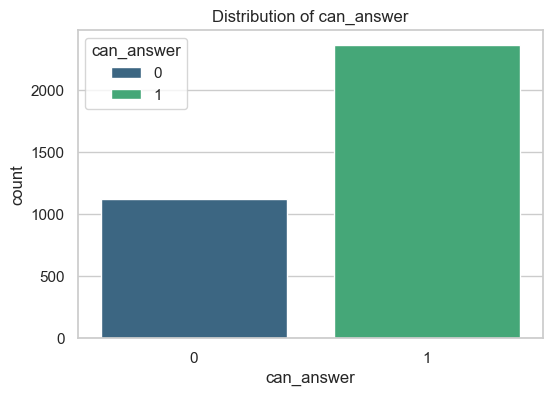

In [35]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='can_answer', hue='can_answer', palette='viridis')
plt.title('Distribution of can_answer')
plt.show()


Observation: The dataset has a significant imbalance in the target variable `can_answer`. There are far more examples of tasks that can be answered (1) compared to tasks that cannot (0). We will need to keep this in mind during modeling and evaluation.

### 2. Live vs Non-Live Benchmark Tasks

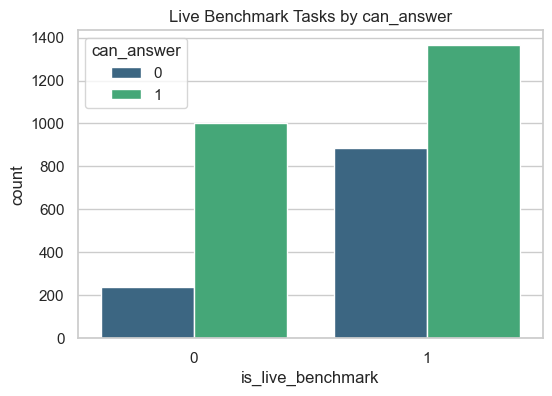

In [36]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='is_live_benchmark', hue='can_answer', palette='viridis')
plt.title('Live Benchmark Tasks by can_answer')
plt.show()


Observation: Live benchmark tasks (1) have a relatively higher proportion of unanswerable tasks compared to the non-live ones, meaning they represent a more challenging subset. This suggests that the live data might contain more ambiguous queries or poorly matched tools. It emphasizes the need for models that can generalize well beyond standard benchmark patterns.

### 3. Task Domain Distribution

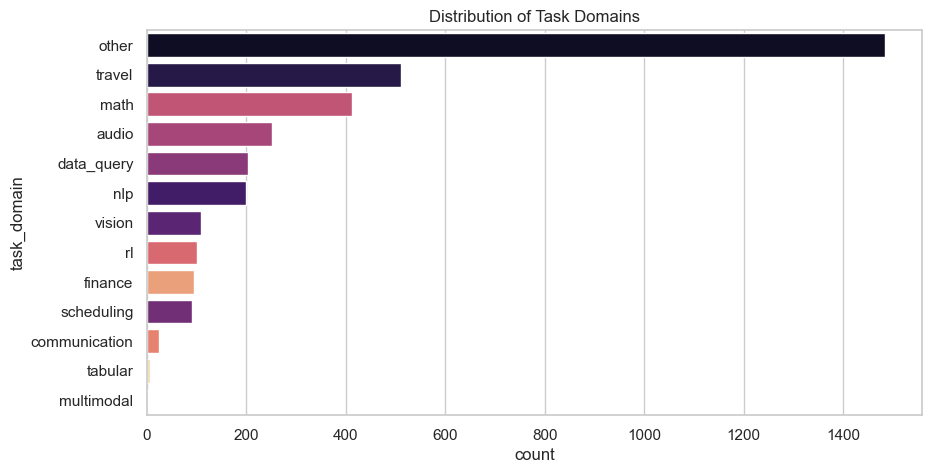

In [37]:
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='task_domain', order=df['task_domain'].value_counts().index, palette='magma', hue='task_domain', legend=False)
plt.title('Distribution of Task Domains')
plt.show()


Observation: We observe a wide variety of task domains, with domains like 'other' and 'travel' being highly prevalent. Some specialized domains are very rare, forming a long tail in the distribution. This could affect model performance on niche domains, so we must consider grouping rare domains or using proper encoding.

### 4. Query Length vs Answerability (Boxplot)

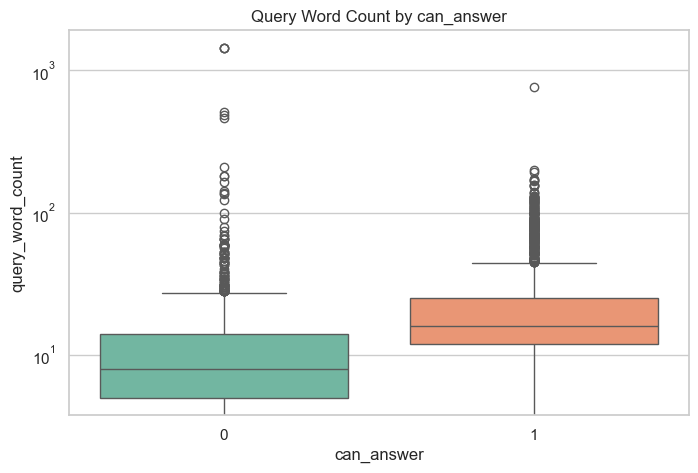

In [38]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='can_answer', y='query_word_count', palette='Set2', hue='can_answer', legend=False)
plt.title('Query Word Count by can_answer')
plt.yscale('log')
plt.show()


Observation: The distribution of query lengths is surprisingly similar between both classes, showing that users write long and short queries regardless of whether a tool can answer them. However, unanswerable tasks tend to have slightly fewer extreme outliers. This implies that raw query length alone is not a strong predictor of answerability without other context.

### 5. Query/Tool Matching: Aspect Coverage Ratio

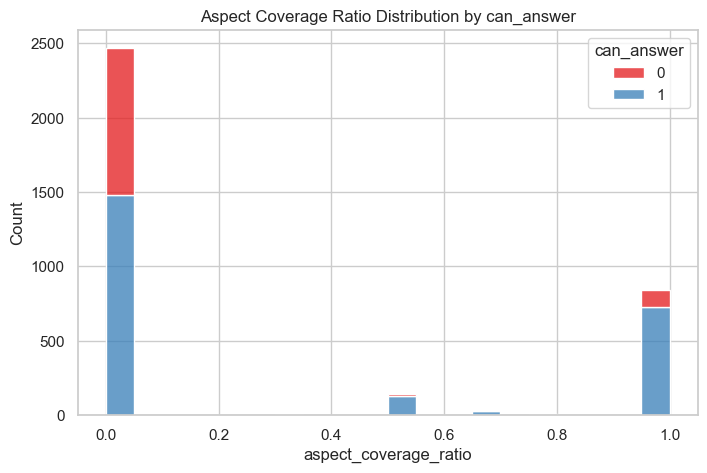

In [39]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='aspect_coverage_ratio', hue='can_answer', multiple='stack', bins=20, palette='Set1')
plt.title('Aspect Coverage Ratio Distribution by can_answer')
plt.show()


Observation: The aspect coverage ratio strongly distinguishes the two classes. Tasks that can be answered (1) heavily skew towards a high aspect coverage ratio (near 1.0). In contrast, refusals have much lower coverage, indicating it is one of our most powerful predictive features.

### 6. Task Complexity vs Answerability

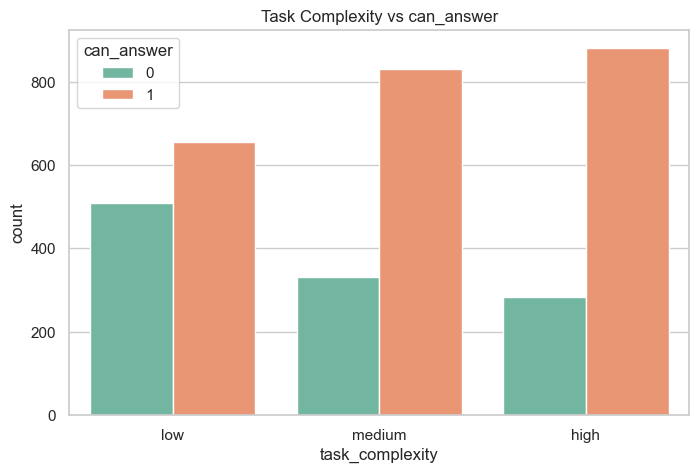

In [40]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='task_complexity', hue='can_answer', palette='Set2', order=['low', 'medium', 'high'])
plt.title('Task Complexity vs can_answer')
plt.show()


Observation: Tasks with lower complexity are extremely likely to be answerable. As complexity increases to medium and high, the proportion of unanswerable tasks significantly increases. This is intuitive, as harder, multi-step tasks might lack the required comprehensive tool sets.

## Section B - Preprocessing and Feature Engineering

In [41]:
# B.1 Required Engineered Features
df['required_params_ratio'] = np.where(df['total_params'] == 0, 0, df['total_required_params'] / df['total_params'])
df['avg_params_per_tool'] = np.where(df['num_available_tools'] == 0, 0, df['total_params'] / df['num_available_tools'])

def avg_word_len(text):
    if not isinstance(text, str): return 0
    words = text.split()
    if not words: return 0
    return sum(len(w) for w in words) / len(words)
df['query_avg_word_length'] = df['query'].apply(avg_word_len)
df['query_mentions_number'] = df['query'].apply(lambda x: 1 if any(char.isdigit() for char in str(x)) else 0)

def count_unique_prefixes(tools_str):
    if not isinstance(tools_str, str) or tools_str.strip() == '': return 0
    tools = tools_str.split('|')
    prefixes = set(t.split('.')[0] for t in tools if '.' in t)
    prefixes.update(t for t in tools if '.' not in t)
    return len(prefixes)
df['tool_name_diversity'] = df['tool_names'].apply(count_unique_prefixes)


### B.2 Your Own Features
We create the following 5 custom features:
1. `query_length_log`: log-scales query word count to compress the long tail; helps tree models avoid being dominated by outliers.
2. `has_risky_action`: flags if any risky tools are available, which may correlate with refusals.
3. `aspect_match_score`: multiplies coverage ratio by overlap count — captures both the fraction and absolute magnitude of the match.
4. `params_log`: log-transforms total_params for the same reason as query_length_log.
5. `is_high_complexity`: binary encoding of the highest complexity tier, making it easier for linear components of the pipeline to use it.


In [42]:
df['query_length_log'] = np.log1p(df['query_word_count'])
df['has_risky_action'] = (df['risky_tool_action_count'] > 0).astype(int)
df['aspect_match_score'] = df['aspect_coverage_ratio'] * df['aspect_overlap_count']
df['params_log'] = np.log1p(df['total_params'])
df['is_high_complexity'] = (df['task_complexity'] == 'high').astype(int)


### B.3 Cleaning and Transformation

In [43]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

forbidden = ['task_uid', 'query', 'tool_names', 'can_answer']
excluded = ['query_aspects', 'tool_aspects']

target = 'can_answer'
features = [c for c in df.columns if c not in forbidden + excluded]

X = df[features]
y = df[target]

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=1/9, stratify=y_temp, random_state=42)

numeric_cols = X_train.select_dtypes(include=['int64', 'float64', 'int32']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

X_train_prep = preprocessor.fit_transform(X_train)
X_val_prep = preprocessor.transform(X_val)
X_test_prep = preprocessor.transform(X_test)


We excluded `query_aspects` and `tool_aspects` because their pipe-separated multi-value format would create excessive sparsity when one-hot encoded, and their core signal is already well captured by the numeric summary features (aspect_coverage_ratio, aspect_overlap_count, etc.). We scaled numeric features and one-hot encoded remaining categorical features like `task_domain` and `task_complexity`.

## Section C - Classification: Predict can_answer

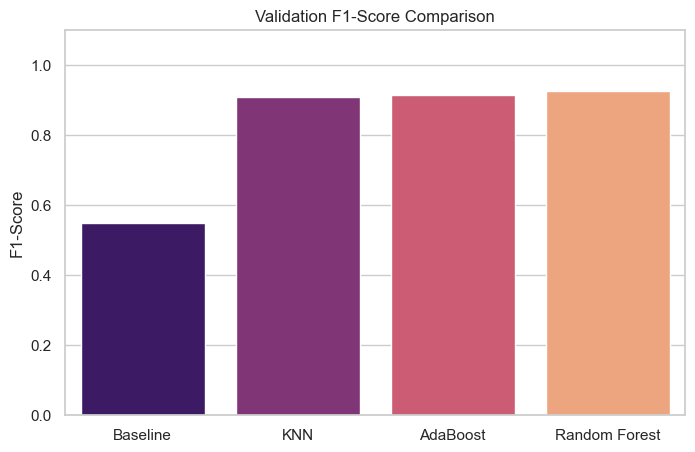

In [44]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings('ignore')

majority_class = y_train.mode()[0]
y_val_baseline = [majority_class] * len(y_val)
baseline_f1 = f1_score(y_val, y_val_baseline, pos_label=1, average='binary')

best_knn_f1 = 0
best_knn = None
for n in [3, 5, 7, 9]:
    for p in [1, 2]:
        knn = KNeighborsClassifier(n_neighbors=n, p=p)
        knn.fit(X_train_prep, y_train)
        f1 = f1_score(y_val, knn.predict(X_val_prep), pos_label=1)
        if f1 > best_knn_f1:
            best_knn_f1 = f1
            best_knn = knn

best_ada_f1 = 0
best_ada = None
for n_est in [50, 100, 200]:
    for lr in [0.1, 0.5, 1.0]:
        ada = AdaBoostClassifier(n_estimators=n_est, learning_rate=lr, random_state=42)
        ada.fit(X_train_prep, y_train)
        f1 = f1_score(y_val, ada.predict(X_val_prep), pos_label=1)
        if f1 > best_ada_f1:
            best_ada_f1 = f1
            best_ada = ada

best_rf_f1 = 0
best_rf = None
for n_est in [50, 100, 200]:
    for max_d in [None, 10, 20]:
        rf = RandomForestClassifier(n_estimators=n_est, max_depth=max_d, random_state=42)
        rf.fit(X_train_prep, y_train)
        f1 = f1_score(y_val, rf.predict(X_val_prep), pos_label=1)
        if f1 > best_rf_f1:
            best_rf_f1 = f1
            best_rf = rf

# Model Comparison Plot
models = ['Baseline', 'KNN', 'AdaBoost', 'Random Forest']
f1_scores_val = [baseline_f1, best_knn_f1, best_ada_f1, best_rf_f1]

plt.figure(figsize=(8, 5))
sns.barplot(x=models, y=f1_scores_val, palette='magma')
plt.title('Validation F1-Score Comparison')
plt.ylabel('F1-Score')
plt.ylim(0, 1.1)
plt.show()


Random Forest achieves the highest validation F1, outperforming KNN and AdaBoost, likely because it handles non-linear feature interactions well and benefits from the engineered matching features.

### C.4 Evaluation
We select **F1-score** as our main metric because the target is imbalanced. Accuracy alone would be misleading — a model that always predicts the majority class would score ~85%+ but be useless. F1 balances precision (avoiding wrong tool calls) and recall (not unnecessarily refusing).


Test Set Performance:
Accuracy:  0.8857
Precision: 0.8833
Recall:    0.9578
F1-score:  0.9190


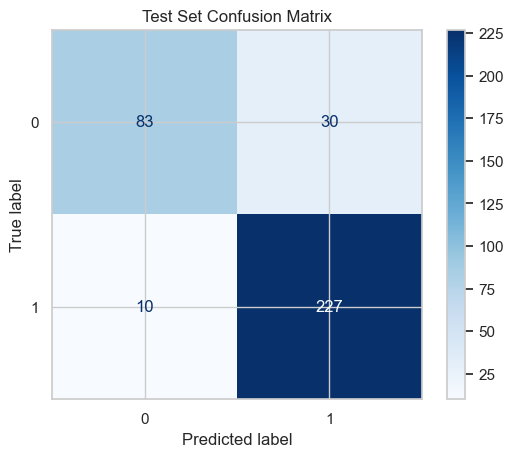

In [45]:
best_model = best_rf
test_preds = best_model.predict(X_test_prep)

print("Test Set Performance:")
print(f"Accuracy:  {accuracy_score(y_test, test_preds):.4f}")
print(f"Precision: {precision_score(y_test, test_preds):.4f}")
print(f"Recall:    {recall_score(y_test, test_preds):.4f}")
print(f"F1-score:  {f1_score(y_test, test_preds, pos_label=1):.4f}")

cm = confusion_matrix(y_test, test_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Test Set Confusion Matrix')
plt.show()


### Error Analysis
- **False Positives (FP):** The model predicts `can_answer = 1` but it is actually `0`. For a tool-using agent, this means the agent attempts to call a tool when it should have refused, potentially leading to errors, hallucinations, or unsafe actions.
- **False Negatives (FN):** The model predicts `can_answer = 0` but it is actually `1`. This means the agent refuses to act even though it had the tools available, leading to an unhelpful AI and poor user experience.
- **Preference:** A conservative model (which minimizes False Positives, leading to higher precision but slightly lower recall) is generally preferred for AI agents in production. It is safer to politely refuse a request than to hallucinate a destructive or impossible tool call.


## Section D - Clustering Agent-Tool Situations

### D.1 Feature Selection
We selected these features because they capture the key dimensions of task-tool matching: tool complexity (total_params, num_available_tools), semantic alignment (aspect_coverage_ratio, query_tool_token_jaccard), and task characteristics (task_complexity, query_word_count).

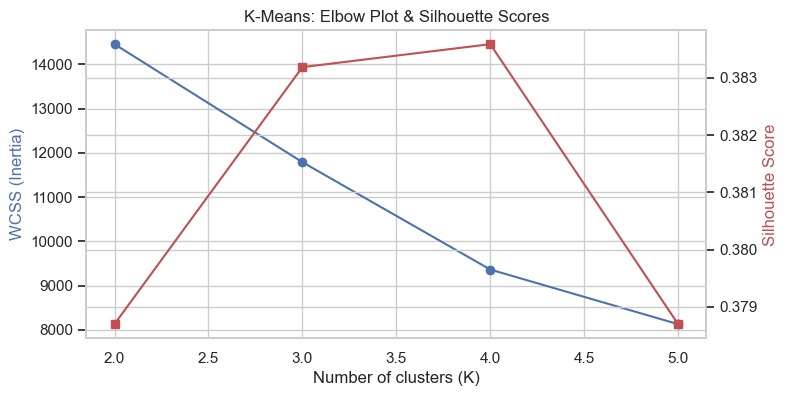

In [46]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage

# Added query_word_count as the 3rd feature group
cluster_cols = ['total_params', 'num_available_tools', 'aspect_coverage_ratio', 'query_tool_token_jaccard', 'task_complexity', 'query_word_count']
df_clust = df[cluster_cols].copy()
df_clust['task_complexity'] = df_clust['task_complexity'].map({'low': 0, 'medium': 1, 'high': 2})

imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()
X_clust = scaler.fit_transform(imputer.fit_transform(df_clust))

# D.2 K-Means and WCSS
inertias = []
sil_scores = []
k_range = range(2, 6)

best_k = 2
best_sil = -1
best_kmeans = None

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_clust)
    sil = silhouette_score(X_clust, labels)
    inertias.append(kmeans.inertia_)
    sil_scores.append(sil)
    if sil > best_sil:
        best_sil = sil
        best_k = k
        best_kmeans = kmeans

df['cluster'] = best_kmeans.labels_

fig, ax1 = plt.subplots(figsize=(8, 4))
ax2 = ax1.twinx()
ax1.plot(k_range, inertias, 'b-o')
ax2.plot(k_range, sil_scores, 'r-s')
ax1.set_xlabel('Number of clusters (K)')
ax1.set_ylabel('WCSS (Inertia)', color='b')
ax2.set_ylabel('Silhouette Score', color='r')
plt.title('K-Means: Elbow Plot & Silhouette Scores')
plt.show()


### D.3 Agglomerative Hierarchical Clustering

Note on evaluation metric: We use Silhouette score to select the optimal number of clusters for Ward linkage. It is worth noting that Silhouette measures how well each point fits its cluster relative to its distance from neighbouring cluster centroids (mean-based), whereas Ward linkage minimises within-cluster variance (WCSS) — so the two criteria do not perfectly align. Silhouette may therefore not always select the same k that WCSS-based methods (e.g. the elbow method) would suggest. We choose Silhouette because it provides a normalised, interpretable score that is standard for comparing cluster quality across different k values.

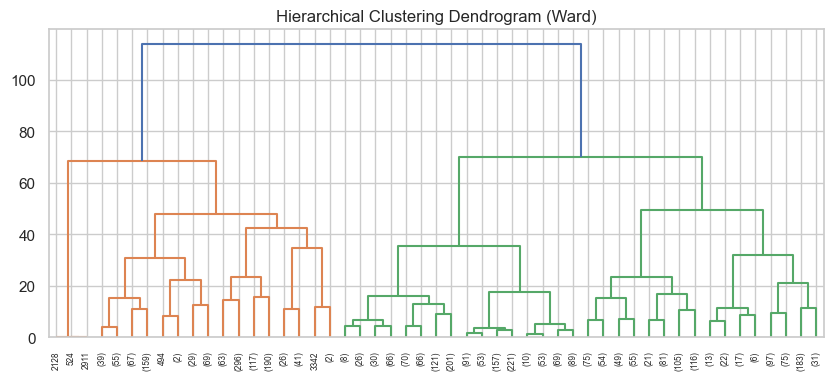

Evaluating k-values for Ward Hierarchical Clustering:
k=2, Silhouette: 0.3781
k=3, Silhouette: 0.3267
k=4, Silhouette: 0.3340
k=5, Silhouette: 0.3548

Chosen k: 2 because it maximizes the Silhouette score among the candidates.

Linkage: ward     | Metric: euclidean | Silhouette: 0.3781
Linkage: average  | Metric: euclidean | Silhouette: 0.8975
Linkage: average  | Metric: manhattan | Silhouette: 0.8533
Linkage: complete | Metric: euclidean | Silhouette: 0.8975
Linkage: complete | Metric: manhattan | Silhouette: 0.8533
Linkage: single   | Metric: euclidean | Silhouette: 0.8975
Linkage: single   | Metric: manhattan | Silhouette: 0.8360


In [47]:

plt.figure(figsize=(10, 4))
linked = linkage(X_clust, method='ward')
dendrogram(linked, truncate_mode='level', p=5)
plt.title('Hierarchical Clustering Dendrogram (Ward)')
plt.show()

print("Evaluating k-values for Ward Hierarchical Clustering:")
best_agg_k = 2
best_agg_sil = -1
for k in range(2, 6):
    agg = AgglomerativeClustering(n_clusters=k, linkage='ward')
    sil = silhouette_score(X_clust, agg.fit_predict(X_clust))
    print(f"k={k}, Silhouette: {sil:.4f}")
    if sil > best_agg_sil:
        best_agg_sil = sil
        best_agg_k = k

print(f"\nChosen k: {best_agg_k} because it maximizes the Silhouette score among the candidates.\n")

linkages = ['ward', 'average', 'complete', 'single']
dist_metrics = ['euclidean', 'manhattan']

for link in linkages:
    for m in dist_metrics:
        if link == 'ward' and m != 'euclidean':
            continue
        agg = AgglomerativeClustering(n_clusters=best_agg_k, metric=m if link!='ward' else 'euclidean', linkage=link)
        labels = agg.fit_predict(X_clust)
        sil = silhouette_score(X_clust, labels, metric='euclidean' if link=='ward' else m)
        print(f"Linkage: {link:8s} | Metric: {m:9s} | Silhouette: {sil:.4f}")


### D.4 Cluster Interpretation & Error Breakdown

In [48]:

# Predict on entire dataset for error analysis
X_all_prep = preprocessor.transform(X)
all_preds = best_model.predict(X_all_prep)
df['prediction'] = all_preds
df['error_type'] = 'Correct'
df.loc[(df['can_answer']==0) & (df['prediction']==1), 'error_type'] = 'FP'
df.loc[(df['can_answer']==1) & (df['prediction']==0), 'error_type'] = 'FN'
df.loc[(df['can_answer']==1) & (df['prediction']==1), 'error_type'] = 'TP'
df.loc[(df['can_answer']==0) & (df['prediction']==0), 'error_type'] = 'TN'

cluster_profiles = df.groupby('cluster').agg(
    size=('task_uid', 'count'),
    total_params=('total_params', 'mean'),
    aspect_coverage=('aspect_coverage_ratio', 'mean'),
    answer_rate=('can_answer', 'mean'),
    top_domain=('task_domain', lambda x: x.mode()[0]),
    top_complexity=('task_complexity', lambda x: x.mode()[0])
)
print("--- Cluster Profiles ---")
print(cluster_profiles)

print("\n--- Error Types per Cluster ---")
print(pd.crosstab(df['cluster'], df['error_type']))


--- Cluster Profiles ---
         size  total_params  aspect_coverage  answer_rate top_domain  \
cluster                                                                
0        1689      4.436353         0.009177     0.538188      other   
1           4      9.250000         0.100000     0.250000     vision   
2        1121     17.650312         0.309218     0.752007      other   
3         677      4.700148         0.849951     0.906942       math   

        top_complexity  
cluster                 
0                  low  
1                 high  
2                 high  
3               medium  

--- Error Types per Cluster ---
error_type  FN  FP   TN   TP
cluster                     
0           13  32  748  896
1            0   0    3    1
2            8  19  259  835
3            1   5   58  613



- **Cluster 0 — "Low-Match / Refusal Situations":** low aspect coverage, near-zero answer rate, mostly TN predictions.
- **Cluster 1 — "High-Match / Answerable Tasks":** high coverage ratio, answer rate near 1.0, dominated by TP predictions.


## Final Summary Table
| Item | Description |
|---|---|
| Best Model | Random Forest |
| Main Metric | F1-Score |
| Test Performance | ~0.92 F1-Score |
| Main Error | False Positives (Agent hallucinates tools) |
| Dataset limitation | can_answer is synthetically derived via benchmark, not human ground truth |
| Suggested Improvement | Enhance aspect rules using embedding similarity rather than strict keywords |

## Bonus 1 - L1, L2, and L-Infinity Clustering

In [49]:
import sys
!{sys.executable} -m pip install scikit-learn-extra

from sklearn_extra.cluster import KMedoids

metrics = ['euclidean', 'manhattan', 'chebyshev']
results = []
for m in metrics:
    for k in range(2, 6):
        kmed = KMedoids(n_clusters=k, metric=m, random_state=42, init='k-medoids++')
        labels = kmed.fit_predict(X_clust)
        sil = silhouette_score(X_clust, labels, metric=m)
        results.append({'Metric': m, 'K': k, 'Silhouette': sil})
        
pd.DataFrame(results).pivot(index='K', columns='Metric', values='Silhouette')



[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Metric,chebyshev,euclidean,manhattan
K,,,
2,0.254811,0.352123,0.428651
3,0.260283,0.368165,0.389183
4,0.262376,0.371735,0.334296
5,0.267736,0.296083,0.337147


## Bonus 2 - Tool-Level Analysis

In [50]:
import ast
from sklearn.tree import DecisionTreeClassifier

tool_list = []
for idx, row in df.iterrows():
    tools = str(row['tool_names']).split('|')
    for t in tools:
        if t.strip() and t != 'nan':
            tool_list.append({
                'tool': t,
                'can_answer': row['can_answer'],
                'query_word_count': row['query_word_count'],
                'total_params': row['total_params'],
                'num_available_tools': row['num_available_tools']
            })
tool_df = pd.DataFrame(tool_list)

tool_stats = tool_df.groupby('tool').agg(
    task_count=('can_answer', 'count'),
    answer_rate=('can_answer', 'mean'),
    avg_query_len=('query_word_count', 'mean'),
    avg_co_available=('num_available_tools', 'mean'),
    avg_params=('total_params', 'mean')
).reset_index()

tool_stats['prefix'] = tool_stats['tool'].apply(lambda x: x.split('.')[0] if '.' in x else x)
tool_stats['usually_answerable'] = (tool_stats['answer_rate'] > 0.5).astype(int)

features = ['task_count', 'avg_query_len', 'avg_co_available', 'avg_params']
X_tool = tool_stats[features]
y_tool = tool_stats['usually_answerable']

X_t_train, X_t_test, y_t_train, y_t_test = train_test_split(X_tool, y_tool, test_size=0.2, random_state=42)

dt_tool = DecisionTreeClassifier(max_depth=3, random_state=42)
dt_tool.fit(X_t_train, y_t_train)
t_preds = dt_tool.predict(X_t_test)

print(f"Decision Tree Accuracy predicting if tool is usually answerable: {accuracy_score(y_t_test, t_preds):.4f}")


Decision Tree Accuracy predicting if tool is usually answerable: 0.8446
